Critical Diameter for Re = 1: 13.87 μm

Iteration Details for Diameter: 60 μm
It.  Cd             Re             Vt_dem         Vt_new (m/s)   
------------------------------------------------------------
1    100.703822     0.252198       0.152313       0.062360       
2    103.484222     0.245162       0.148064       0.061517       
3    104.850313     0.241846       0.146061       0.061115       
4    105.514707     0.240266       0.145107       0.060922       
5    105.836251     0.239508       0.144649       0.060829       
6    105.991499     0.239144       0.144429       0.060785       
7    106.066370     0.238969       0.144323       0.060763       
8    106.102459     0.238884       0.144272       0.060753       
9    106.119849     0.238844       0.144248       0.060748       
--------------------------------------------------------------------------------

Iteration Details for Diameter: 100 μm
It.  Cd             Re             Vt_dem         Vt_new (m/s)   
--------------

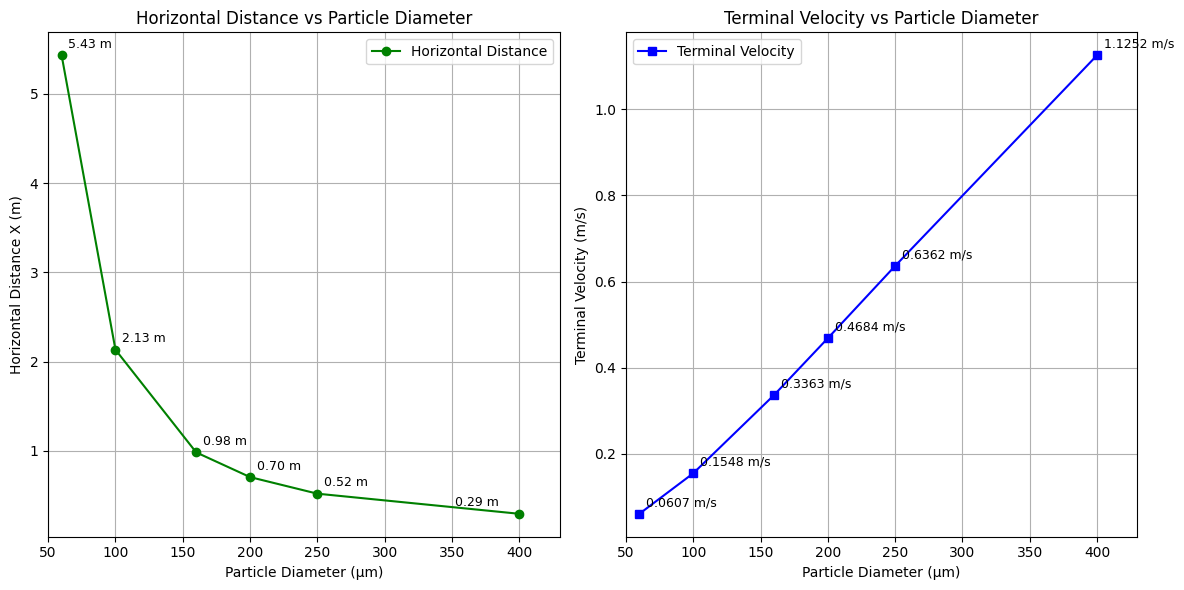

,Diameter (μm),Vt (m/s),X (m),Iterations,Fit in Hole,Re (horizontal)
0,60.0,0.0607,5.4323,9,2519166,4.32
1,100.0,0.1548,2.1323,10,906900,7.21
2,160.0,0.3363,0.9813,11,354257,11.53
3,200.0,0.4684,0.7045,11,226725,14.42
4,250.0,0.6362,0.5187,11,145104,18.02
5,400.0,1.1252,0.2933,11,56681,28.83


,Diameter (μm),Vt (m/s),X (m),Iterations,Fit in Hole,Re (horizontal),X_corrected (m)
0,60.0,0.0607,5.4323,9,2519166,4.32,4.88907
1,100.0,0.1548,2.1323,10,906900,7.21,1.91907
2,160.0,0.3363,0.9813,11,354257,11.53,0.88317
3,200.0,0.4684,0.7045,11,226725,14.42,0.63405
4,250.0,0.6362,0.5187,11,145104,18.02,0.46683
5,400.0,1.1252,0.2933,11,56681,28.83,0.26397


,Diameter (μm),Vt (m/s),X_scaled (30 m height) (m)
0,60.0,0.0607,543.2284
1,100.0,0.1548,213.2260
2,160.0,0.3363,98.1271
3,200.0,0.4684,70.4535
4,250.0,0.6362,51.8709
5,400.0,1.1252,29.3275


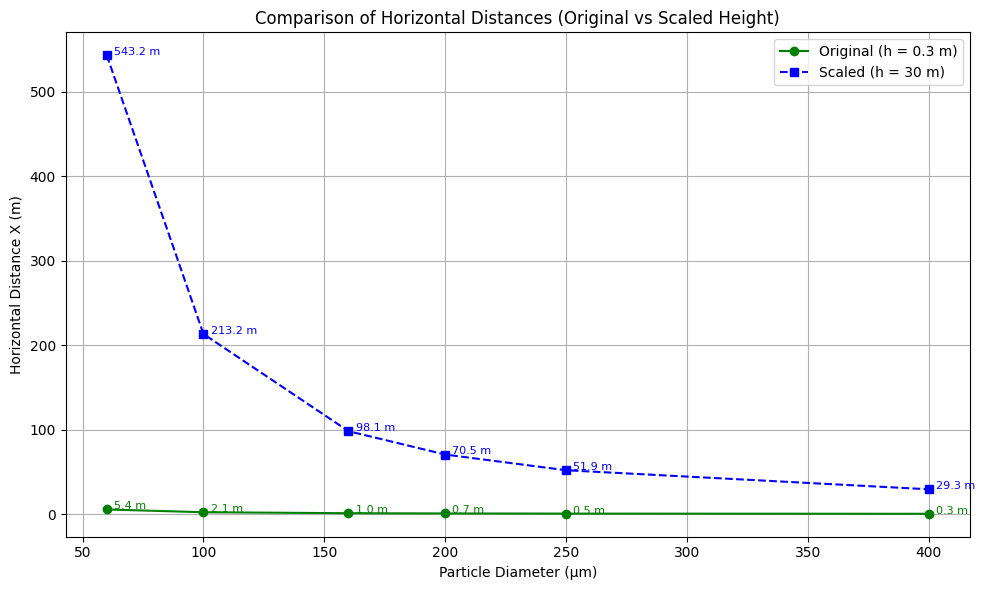

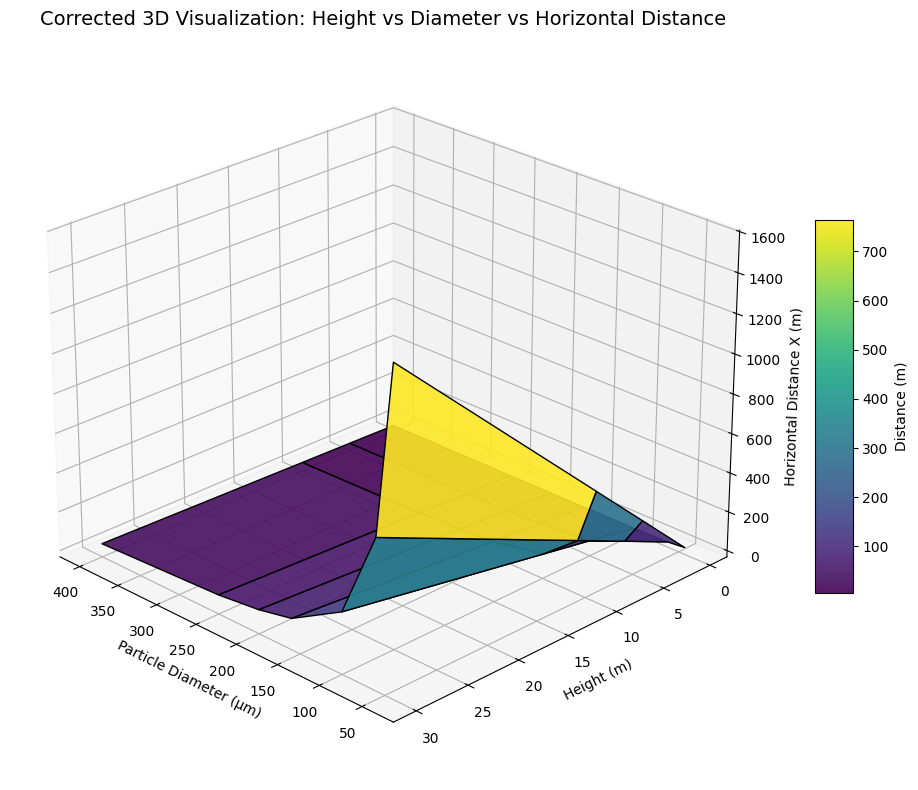

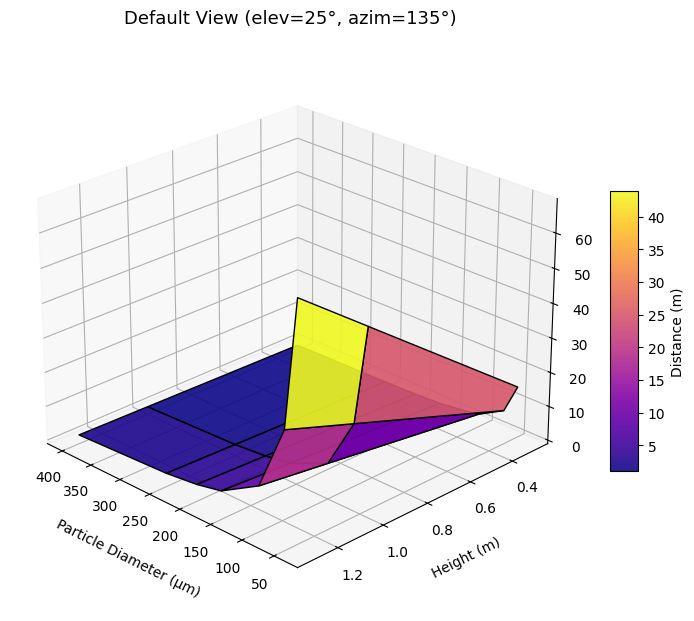

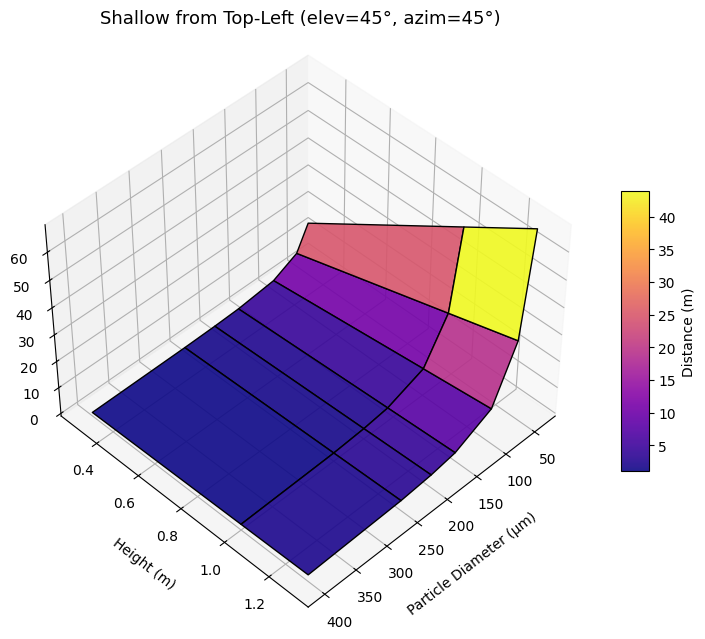

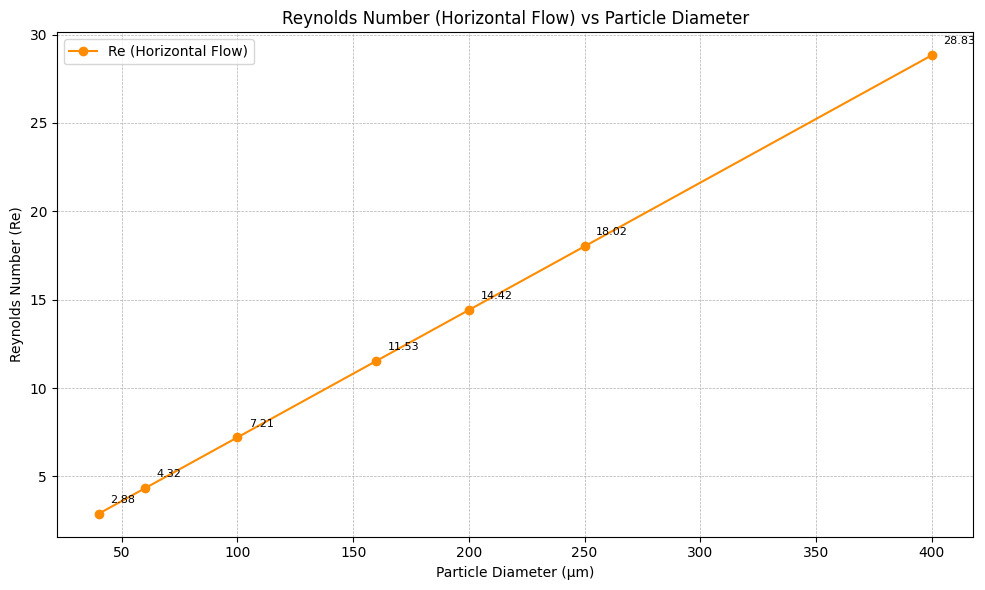

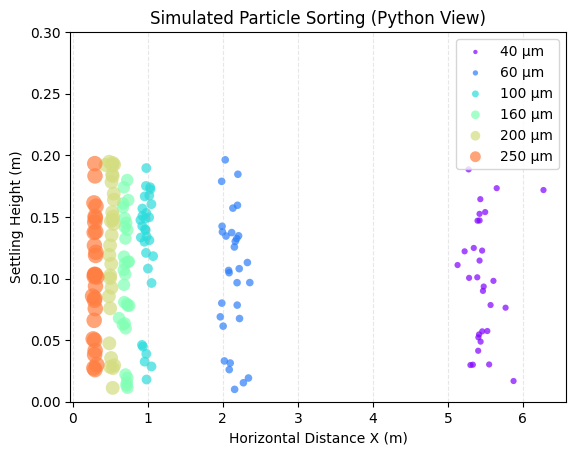

In [3]:
import math
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import numpy as np
# --- Constants ---
rho_p = 600                  # Particle density [kg/m^3]
rho_air = 1.2                # Air density [kg/m^3]
mu = 1.83141e-5              # Dynamic viscosity of air [Pa·s]
g = 9.81                     # Gravity [m/s^2]
eps_tol = 1e-5               # Convergence tolerance
h = 0.3                      # Vertical fall height [m]
Vh = 1.1                     # Horizontal airflow velocity [m/s]
D_hole = 0.1                 # Diameter of the hole [m]
packing_efficiency = 0.9069 # Hexagonal packing efficiency
A_hole = math.pi * (D_hole / 2)**2  # Area of the hole

# --- Critical Diameter Calculation ---
d_crit = mu / (rho_air * Vh)
print(f"Critical Diameter for Re = 1: {d_crit*1e6:.2f} μm")

# --- Particle diameters (in meters) ---
diameters = [60e-6, 100e-6, 160e-6, 200e-6, 250e-6, 400e-6]
X_values = []
Vt_values = []
iterations_list = []

results_table = []

# --- Loop over each particle diameter ---
for d in diameters:
    Vt_old = ((rho_p - rho_air) * g * d**2) / (18 * mu)
    ddem = d * ((rho_air * (rho_p - rho_air) * g) / (mu**2))**(1/3)
    iteration_data = []
    iteration = 0

    while True:
        iteration += 1
        Vt_dem = Vt_old * ((rho_air**2) / (mu * (rho_p - rho_air) * g))**(1/3)
        Re_iter = ddem * Vt_dem
        cD = (24 / Re_iter) * (1 + 0.15 * Re_iter**0.687)
        Vt_new = math.sqrt((4 * g * d * (rho_p - rho_air)) / (3 * rho_air * cD))

        iteration_data.append([
            iteration,
            cD,
            Re_iter,
            Vt_dem,
            Vt_new
        ])

        if abs(Vt_new - Vt_old) < eps_tol:
            break
        Vt_old = Vt_new

    Vt_values.append(Vt_new)
    X = (Vh * h) / Vt_new
    X_values.append(X)
    iterations_list.append(iteration)

    A_particle = math.pi * (d / 2)**2
    Particlefit = int((A_hole / A_particle) * packing_efficiency)

    # Reynolds number for horizontal airflow
    Re_horizontal = (rho_air * Vh * d) / mu

    results_table.append({
        "Diameter (μm)": round(d * 1e6, 0),
        "Vt (m/s)": round(Vt_new, 4),
        "X (m)": round(X, 4),
        "Iterations": iteration,
        "Fit in Hole": Particlefit,
        "Re (horizontal)": round(Re_horizontal, 2)
    })

    # Print iteration table
    print(f"\nIteration Details for Diameter: {d*1e6:.0f} μm")
    print(f"{'It.':<5}{'Cd':<15}{'Re':<15}{'Vt_dem':<15}{'Vt_new (m/s)':<15}")
    print("-"*60)
    for row in iteration_data:
        print(f"{row[0]:<5}{row[1]:<15.6f}{row[2]:<15.6f}{row[3]:<15.6f}{row[4]:<15.6f}")
    print("-"*80)

# --- Plotting ---
plt.figure(figsize=(12, 6))
diameter_microns = [d * 1e6 for d in diameters]

# Subplot 1: Horizontal Distance
plt.subplot(1, 2, 1)
plt.plot(diameter_microns, X_values, marker='o', linestyle='-', color='green', label="Horizontal Distance")
for i, (d_micro, X) in enumerate(zip(diameter_microns, X_values)):
    offset = -15 if i == len(diameter_microns) - 1 else 5
    ha_align = 'right' if i == len(diameter_microns) - 1 else 'left'
    plt.text(d_micro + offset, X + 0.05, f"{X:.2f} m", fontsize=9, ha=ha_align, va='bottom')

plt.xlim(min(diameter_microns) - 10, max(diameter_microns) + 30)
plt.title("Horizontal Distance vs Particle Diameter")
plt.xlabel("Particle Diameter (μm)")
plt.ylabel("Horizontal Distance X (m)")
plt.grid(True)
plt.legend()

# Subplot 2: Terminal Velocity
plt.subplot(1, 2, 2)
plt.plot(diameter_microns, Vt_values, marker='s', linestyle='-', color='blue', label="Terminal Velocity")
for i, (d_micro, Vt) in enumerate(zip(diameter_microns, Vt_values)):
    plt.text(d_micro + 5, Vt + 0.01, f"{Vt:.4f} m/s", fontsize=9, ha='left', va='bottom')

plt.xlim(min(diameter_microns) - 10, max(diameter_microns) + 30)
plt.title("Terminal Velocity vs Particle Diameter")
plt.xlabel("Particle Diameter (μm)")
plt.ylabel("Terminal Velocity (m/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Display table ---
df = pd.DataFrame(results_table)
display(df)
# Add 10% error correction to horizontal distance
df = pd.DataFrame(results_table)
df["X_corrected (m)"] = df["X (m)"] * 0.9  # Apply 10% correction

# Display updated table with error-corrected distance
display(df)
# Create a scaled-up model where the vertical height is 30 meters
h_scaled = 30  # meters

# Calculate scaled horizontal distances based on original terminal velocities
X_scaled_values = [(Vh * h_scaled) / vt for vt in Vt_values]

# Create a new DataFrame for scaled model results
scaled_df = pd.DataFrame({
    "Diameter (μm)": [round(d * 1e6, 0) for d in diameters],
    "Vt (m/s)": [round(vt, 4) for vt in Vt_values],
    "X_scaled (30 m height) (m)": [round(x, 4) for x in X_scaled_values]
})

# Display the scaled-up model table
display(scaled_df)
# Plot original vs scaled horizontal distances
plt.figure(figsize=(10, 6))
diameter_microns = [d * 1e6 for d in diameters]

# Plot original
plt.plot(diameter_microns, X_values, marker='o', linestyle='-', color='green', label="Original (h = 0.3 m)")

# Plot scaled
plt.plot(diameter_microns, X_scaled_values, marker='s', linestyle='--', color='blue', label="Scaled (h = 30 m)")

# Annotate both plots
for i, (d_micro, x_orig, x_scaled) in enumerate(zip(diameter_microns, X_values, X_scaled_values)):
    plt.text(d_micro + 3, x_orig + 0.1, f"{x_orig:.1f} m", fontsize=8, color='green')
    plt.text(d_micro + 3, x_scaled + 0.1, f"{x_scaled:.1f} m", fontsize=8, color='blue')

# Labels and title
plt.title("Comparison of Horizontal Distances (Original vs Scaled Height)")
plt.xlabel("Particle Diameter (μm)")
plt.ylabel("Horizontal Distance X (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# Update the diameters list to include 40 μm
diameters = [40e-6, 60e-6, 100e-6, 160e-6, 200e-6, 250e-6, 400e-6]
heights_array = np.array([0.3, 5, 10, 30])  # in meters

# Recalculate terminal velocities for updated diameters
Vt_values_updated = []
for d in diameters:
    Vt_old = ((rho_p - rho_air) * g * d**2) / (18 * mu)
    ddem = d * ((rho_air * (rho_p - rho_air) * g) / (mu**2))**(1/3)
    while True:
        Vt_dem = Vt_old * ((rho_air**2) / (mu * (rho_p - rho_air) * g))**(1/3)
        Re_iter = ddem * Vt_dem
        cD = (24 / Re_iter) * (1 + 0.15 * Re_iter**0.687)
        Vt_new = math.sqrt(ddem / cD) * ((mu * (rho_p - rho_air) * g) / (rho_air**2))**(1/3)
        if abs(Vt_new - Vt_old) < eps_tol:
            break
        Vt_old = Vt_new
    Vt_values_updated.append(Vt_new)

# Prepare data for 3D plot
diameters_array = np.array(diameters)
D, H = np.meshgrid(diameters_array, heights_array)
X_3d = (Vh * H) / np.array(Vt_values_updated)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(D * 1e6, H, X_3d, cmap='viridis', edgecolor='k', alpha=0.9)

# Labels
ax.set_title("Corrected 3D Visualization: Height vs Diameter vs Horizontal Distance", fontsize=14)
ax.set_xlabel("Particle Diameter (μm)")
ax.set_ylabel("Height (m)")
ax.set_zlabel("Horizontal Distance X (m)")
ax.view_init(elev=25, azim=135)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Distance (m)")

plt.tight_layout()
plt.show()
# Define simplified heights and meshgrid to fix the NameError for D_simple
simple_heights = np.array([0.3, 1.0, 1.3])  # in meters
D_simple, H_simple = np.meshgrid(diameters_array, simple_heights)
X_simple = (Vh * H_simple) / np.array(Vt_values_updated)

# Generate the two selected views again with proper variables
selected_views = [
    {"elev": 25, "azim": 135, "title": "Default View (elev=25°, azim=135°)"},
    {"elev": 45, "azim": 45, "title": "Shallow from Top-Left (elev=45°, azim=45°)"}
]

for view in selected_views:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(D_simple * 1e6, H_simple, X_simple, cmap='plasma', edgecolor='k', alpha=0.9)
    
    ax.set_title(view["title"], fontsize=13, pad=20)
    ax.set_xlabel("Particle Diameter (μm)", labelpad=10)
    ax.set_ylabel("Height (m)", labelpad=10)
    ax.set_zlabel("Horizontal Distance X (m)", labelpad=10)
    ax.view_init(elev=view["elev"], azim=view["azim"])
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Distance (m)")
    plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
    plt.show()
# Calculate Re_horizontal again using provided diameters and horizontal velocity
Re_horizontal = [(rho_air * Vh * d) / mu for d in diameters]
diameter_microns = [d * 1e6 for d in diameters]

# Plot Re_horizontal vs Particle Diameter
plt.figure(figsize=(10, 6))
plt.plot(diameter_microns, Re_horizontal, marker='o', linestyle='-', color='darkorange', label="Re (Horizontal Flow)")
import matplotlib.cm as cm
# Annotate each point with the value
for d_micro, Re_val in zip(diameter_microns, Re_horizontal):
    plt.text(d_micro + 5, Re_val + 0.5, f"{Re_val:.2f}", fontsize=8, ha='left', va='bottom')

# Labels and styling
plt.title("Reynolds Number (Horizontal Flow) vs Particle Diameter")
plt.xlabel("Particle Diameter (μm)")
plt.ylabel("Reynolds Number (Re)")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# Use a colormap for a professional look
colors = cm.rainbow(np.linspace(0, 1, len(diameters)))

for i, (d, x_dist) in enumerate(zip(diameters, X_values)):
    # Create the cloud
    x_cloud = np.random.normal(x_dist, x_dist * 0.05, 30) 
    y_cloud = np.random.uniform(0.01, 0.2, 30)
    
    # Plot with specific color and size
    plt.scatter(x_cloud, y_cloud, s=d*1e6/2, color=colors[i], 
                label=f"{d*1e6:.0f} μm", alpha=0.7, edgecolors='none')

plt.title("Simulated Particle Sorting (Python View)")
plt.xlabel("Horizontal Distance X (m)")
plt.ylabel("Settling Height (m)")
plt.ylim(0, 0.3)
plt.legend(loc='upper right', markerscale=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show() 

